# 03 — Modeling

Predict days-to-exploit using CVE features available at disclosure time.

Approach: XGBoost regression on log-transformed outcome. Feature importance gives interpretable signal about what drives faster exploitation — directly relevant to the 221 final framing (AI use case for CTI industry).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

df = pd.read_csv('../data/processed/cve_master.csv')

# Work with exploited CVEs only for regression
exploited = df[df['exploited'] == 1].copy()
exploited = exploited[exploited['days_to_exploit'] >= 0].dropna(subset=['cvss_score'])
print(f"Modeling dataset: {len(exploited)} exploited CVEs")

Modeling dataset: 1371 exploited CVEs


## Feature engineering

In [2]:
cat_cols = ['attack_vector', 'attack_complexity', 'privileges_required', 'user_interaction', 'scope', 'cvss_severity']
num_cols = ['cvss_score', 'epss_score', 'epss_percentile']

# Encode categoricals
for col in cat_cols:
    if col in exploited.columns:
        le = LabelEncoder()
        exploited[col + '_enc'] = le.fit_transform(exploited[col].fillna('UNKNOWN'))

feature_cols = [c + '_enc' for c in cat_cols if c in exploited.columns] + \
               [c for c in num_cols if c in exploited.columns]

X = exploited[feature_cols].fillna(exploited[feature_cols].median())
y = np.log1p(exploited['days_to_exploit'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 1096 | Test: 275


## Train XGBoost

In [3]:
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Convert back from log scale for interpretability
mae_days = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
print(f"MAE (log scale): {mae:.3f}")
print(f"MAE (days):      {mae_days:.1f}")
print(f"R²:              {r2:.3f}")

MAE (log scale): 1.770
MAE (days):      854.1
R²:              0.083


## Feature importance

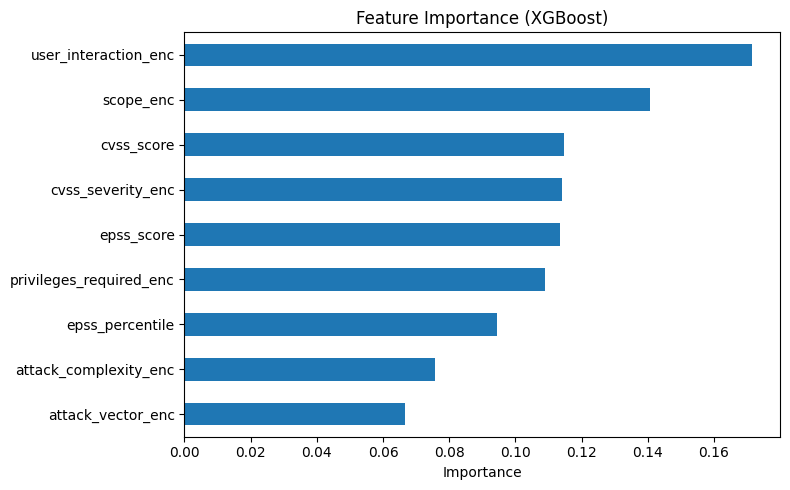

In [4]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax)
ax.set_title('Feature Importance (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Predicted vs. actual

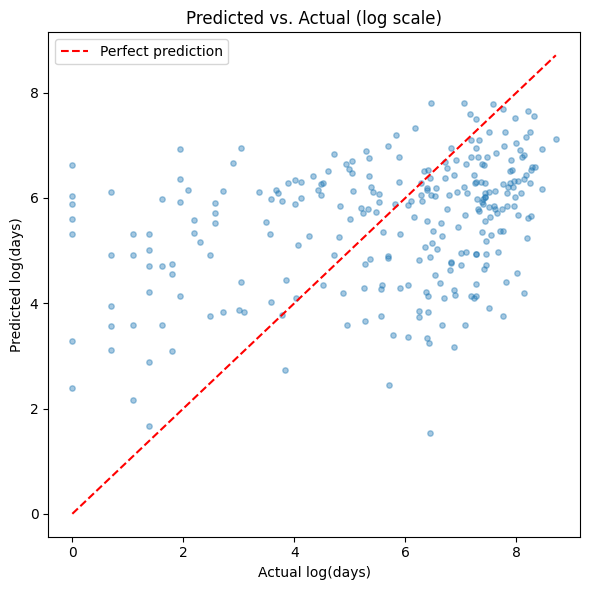

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.4, s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual log(days)')
ax.set_ylabel('Predicted log(days)')
ax.set_title('Predicted vs. Actual (log scale)')
ax.legend()
plt.tight_layout()
plt.show()